In [ ]:
# imports zone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap #shap
from sklearn.preprocessing import StandardScaler # scikit-learn
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve,roc_auc_score, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE #imblearn
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier #xgboost


C:\Users\Jorge\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# problema deste dataset - dados desbalanceados
df["Class"].value_counts(normalize=True)
# 0 OK
# 1 FRAUDE

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [7]:
# Transformação na coluna Amount para aproximar valores e evitar a existência de zeros
df["Amount_log"] = np.log1p(df["Amount"])

In [9]:
# valores com média igual a zero e desvio padrão igual a 1
# ou seja, valores na mesma escala, independente do tamanho original
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [11]:
# Preparando os dados para treinamento
variaveis_entrada =df.drop("Class", axis=1)
target = df["Class"]

variaveis_entrada_train,variaveis_entrada_test,target_train,target_test = train_test_split(variaveis_entrada,target,stratify=target,test_size=0.3,random_state=42)
# 70% treinamento, 30% testes
# stratify => mantém a proporção dos valores em Class.

In [13]:
# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(variaveis_entrada_train,target_train)

y_predi = model.predict(variaveis_entrada_test)

C:\Users\Jorge\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
print(classification_report(target_test,y_predi))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.64      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.82      0.86     85443
weighted avg       1.00      1.00      1.00     85443



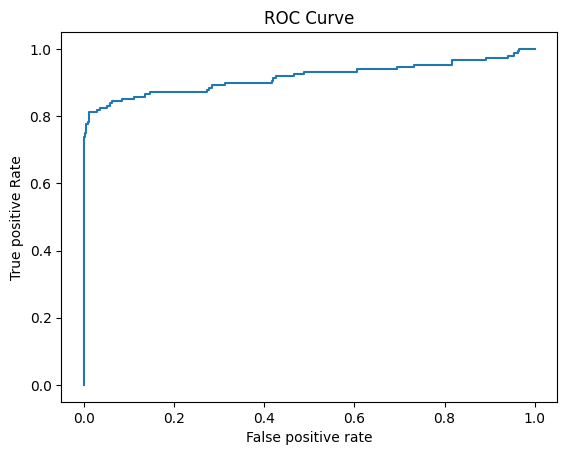

AUC 0.9151502020808545


In [17]:
y_probs = model.predict_proba(variaveis_entrada_test)[:,1]
fpr,tpr,_ = roc_curve(target_test, y_probs)

plt.plot(fpr,tpr)
plt.title("ROC Curve")
plt.xlabel("False positive rate")
plt.ylabel("True positive Rate")
plt.show()

print("AUC", roc_auc_score(target_test,y_probs))

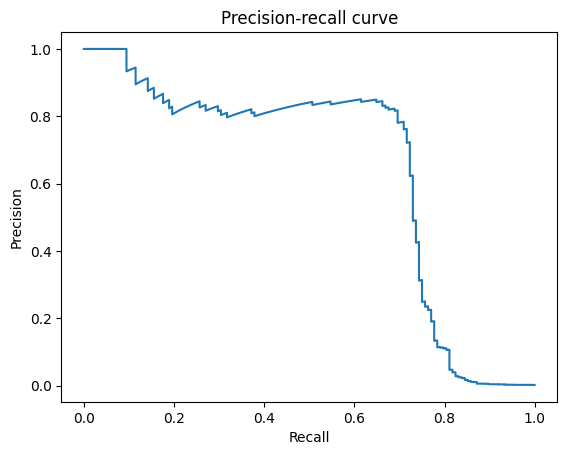

In [19]:
precision,recall,_ = precision_recall_curve(target_test,y_probs)

plt.plot(recall,precision)
plt.title("Precision-recall curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [22]:
# Balanceamento de dados
# Undersampling 
fraudes = df[df["Class"] ==1]
normais = df[df["Class"] ==0].sample(len(fraudes), random_state=42)

df_undesampled = pd.concat([fraudes, normais])


In [23]:
# Balanceamento de dados
# Oversampling
smote = SMOTE()

x_res, y_res = smote.fit_resample(variaveis_entrada, target)

In [24]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(variaveis_entrada_train,target_train)

y_pred_rf = rf.predict(variaveis_entrada_test)

print(classification_report(target_test,y_pred_rf))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.74      0.80      0.77       148

    accuracy                           1.00     85443
   macro avg       0.87      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443



In [26]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(variaveis_entrada_train, target_train)

y_pred = pipeline.predict(variaveis_entrada_test)

In [27]:
threshold = 0.3

y_pred_custom = (y_probs>threshold).astype(int)

print(classification_report(target_test,y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.83      0.68      0.74       148

    accuracy                           1.00     85443
   macro avg       0.91      0.84      0.87     85443
weighted avg       1.00      1.00      1.00     85443



In [29]:
xgb = XGBClassifier(
    scale_pos_weight = 10,
    use_label_encoder = False,
    eval_metric="logloss"
)

xgb.fit(variaveis_entrada_train,target_train)

y_pred_xgb = xgb.predict(variaveis_entrada_test)

print(classification_report(target_test,y_pred_xgb))

C:\Users\Jorge\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:200: UserWarning: [00:44:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



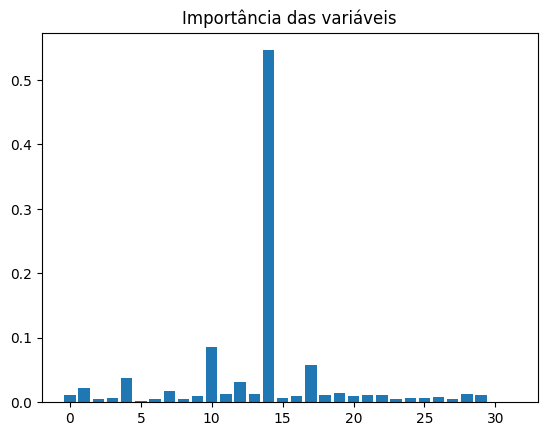

In [30]:
#importancia de variáveis

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)),importancias)
plt.title("Importância das variáveis")
plt.show()

In [32]:
#Ajustes de hiperparâmetros
param_grid = {
    "max_depth": [3,5],
    "n_estimators":[50,100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(variaveis_entrada_train, target_train)

print("melhor modelo: ", grid.best_params_)

melhor modelo:  {'max_depth': 5, 'n_estimators': 100}


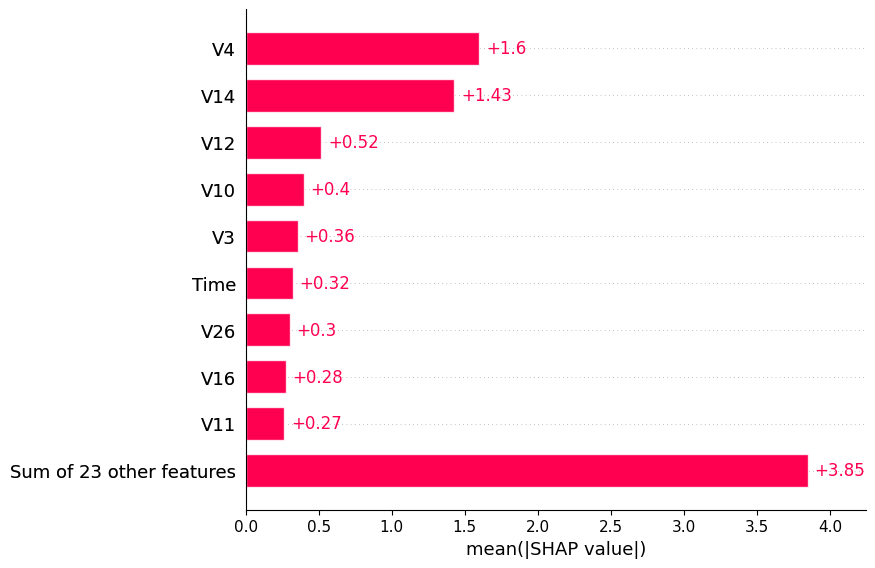

In [35]:
# Explicabilidade

explainer = shap.Explainer(xgb)
shap_values = explainer(variaveis_entrada_test[:100])

shap.plots.bar(shap_values)